This is the data from https://www.met.ie/climate/available-data/historical-data for different wind, wind direction, and precipitation data stations

In [2]:
!pip install geopandas matplotlib
!pip install geodatasets
!pip install rioxarray
!pip install openpyxl

In [3]:
import copernicusmarine
from netCDF4 import Dataset, num2date
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.dates as mdates
import os
import xarray as xr
import rioxarray as rxr
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime
import glob
from scipy import stats
from scipy.stats import linregress
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
from shapely.geometry import MultiPolygon
from shapely import wkb
import pandas as pd
import re
import time
import json

In [56]:
# 1. Define the exact columns you need in the order you want them
master_columns = ['date', 'rain', 'wdsp','hm', 'ddhm','hg'] # Add your specific list here

def load_and_tag_selective(file_path):
    # Read the metadata (using the logic we established previously)
    with open(file_path, 'r') as f:
        line1 = f.readline()
        f.readline()
        line3 = f.readline()

    station_name = line1.split(': ')[1].strip()
    lat = line3.split(',')[0].split(':')[1].strip()
    lon = line3.split(',')[1].split(':')[1].strip()

    # 2. Use 'usecols' to grab ONLY what you need.
    # This ignores the order of the remaining columns!
    df = pd.read_csv(file_path, skiprows=24, usecols=master_columns)

    # 3. Add metadata
    df['Station_Name'] = station_name
    df['Latitude'] = float(lat)
    df['Longitude'] = float(lon)

    return df

# Get all files and combine
file_list = glob.glob("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/WindandPrecipitation data/*.csv")
df_combined = pd.concat([load_and_tag_selective(f) for f in file_list], ignore_index=True)

# 4. Final conversion to ensure numeric types for later analysis
df_combined['Latitude'] = pd.to_numeric(df_combined['Latitude'])
df_combined['Longitude'] = pd.to_numeric(df_combined['Longitude'])

print(df_combined.head())

          date rain  wdsp  hm ddhm  hg  Station_Name  Latitude  Longitude
0  01-dec-1955  9.1  11.5  18  170  24  ROCHES POINT    51.793     -8.244
1  02-dec-1955  0.9  12.1  23  210  32  ROCHES POINT    51.793     -8.244
2  03-dec-1955  0.0   8.0  16  270  21  ROCHES POINT    51.793     -8.244
3  04-dec-1955  1.5   6.3  16  210  23  ROCHES POINT    51.793     -8.244
4  05-dec-1955  0.8  16.5  23  220  32  ROCHES POINT    51.793     -8.244


In [57]:
df_combined

,date,rain,wdsp,hm,ddhm,hg,Station_Name,Latitude,Longitude
0,01-dec-1955,9.1,11.5,18,170,24,ROCHES POINT,51.793,-8.244
1,02-dec-1955,0.9,12.1,23,210,32,ROCHES POINT,51.793,-8.244
2,03-dec-1955,0.0,8.0,16,270,21,ROCHES POINT,51.793,-8.244
3,04-dec-1955,1.5,6.3,16,210,23,ROCHES POINT,51.793,-8.244
4,05-dec-1955,0.8,16.5,23,220,32,ROCHES POINT,51.793,-8.244
...,...,...,...,...,...,...,...,...,...
172444,27-May-26,0.0,8.9,15,70,21,"DUBLIN AIRPORT,,,,,,,,,,,,,,,,,,,,,,,,",53.428,-6.241
172445,28-May-26,0.0,9.3,17,230,26,"DUBLIN AIRPORT,,,,,,,,,,,,,,,,,,,,,,,,",53.428,-6.241
172446,29-May-26,0.0,9.6,15,260,27,"DUBLIN AIRPORT,,,,,,,,,,,,,,,,,,,,,,,,",53.428,-6.241
172447,30-May-26,1.7,6.1,13,220,21,"DUBLIN AIRPORT,,,,,,,,,,,,,,,,,,,,,,,,",53.428,-6.241


Columns: (this was before I selected columns individually before loading)

- date: Date
- rain: Precipitation Amount (mm)
- maxtp: maximumum air temp (C)
- mintp: minimum air temp (C)
- gmin:   -  09utc Grass Minimum Temperature (C)
- soil:   -  Mean 10cm Soil Temperature (C)
- wdsp:   -  Mean Wind Speed (knot)
- "hm:     -  Highest ten minute mean wind speed (knot)		                 "
- ddhm:   -  Wind Direction at max 10 min. mean (deg)
- hg:     -  Highest Gust (knot)
- cbl:    -  Mean CBL Pressure (hpa)
- sun:    -  Sunshine duration (hours)
- "pe:     -  Potential Evapotranspiration (mm)				"
- "evap:   -  Evaporation (mm)						"
- "smd_wd: -  Soil Moisture Deficits(mm) well drained		"
- "smd_md: -  Soil Moisture Deficits(mm) moderately drained	"
- "smd_pd: -  Soil Moisture Deficits(mm) poorly drained 	"
- ind:    -  Indicator (i)
- Station_Name - station name from meta data
- Latitude - latitude
- Longitude - longitude


I want date, rain, wdsp, hm, ddhm, and hg
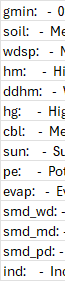

In [58]:
atmo = df_combined[['Station_Name','date', 'rain', 'wdsp','hm', 'ddhm','hg', "Latitude", "Longitude"]]

In [59]:
atmo.rename(columns={'Station_Name':'station', 'Latitude': 'latitude', 'Longitude': 'longitude', 'wdsp':'mean_wind_speed_kt', 'hm':"high_ten_min_mean_kt", 'ddhm':'direction_highten_deg', 'hg':'highest_gust'}, inplace=True)

In [60]:
atmo['date'] = pd.to_datetime(atmo['date'])

C:\Users\25298423\AppData\Local\Temp\ipykernel_12388\2673690428.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  atmo['date'] = pd.to_datetime(atmo['date'])


In [61]:
atmo.dtypes

station                          object
date                     datetime64[ns]
rain                             object
mean_wind_speed_kt               object
high_ten_min_mean_kt             object
direction_highten_deg            object
highest_gust                     object
latitude                        float64
longitude                       float64
dtype: object

In [62]:
cols_to_convert = ['rain', 'mean_wind_speed_kt', 'high_ten_min_mean_kt', 'direction_highten_deg', 'highest_gust']
for col in cols_to_convert:
    atmo[col] = pd.to_numeric(atmo[col], errors='coerce')

In [63]:
atmo.dtypes

station                          object
date                     datetime64[ns]
rain                            float64
mean_wind_speed_kt              float64
high_ten_min_mean_kt            float64
direction_highten_deg           float64
highest_gust                    float64
latitude                        float64
longitude                       float64
dtype: object

In [64]:
atmo.groupby('station')['date'].min()

station
BELMULLET                                1956-09-17
CASEMENT                                 1964-01-01
DUBLIN AIRPORT,,,,,,,,,,,,,,,,,,,,,,,,   1976-01-01
JOHNSTOWN CASTLE 2                       2008-09-19
MACE HEAD                                2003-08-14
MALIN HEAD                               1955-05-01
ROCHES POINT                             1955-12-01
VALENTIA OBSERVATORY                     1942-01-01
Name: date, dtype: datetime64[ns]

In [65]:
atmo['station'].unique()

array(['ROCHES POINT', 'MALIN HEAD', 'JOHNSTOWN CASTLE 2',
       'VALENTIA OBSERVATORY', 'BELMULLET', 'MACE HEAD', 'CASEMENT',
       'DUBLIN AIRPORT,,,,,,,,,,,,,,,,,,,,,,,,'], dtype=object)

In [66]:
atmo['station'] = atmo['station'].str.replace(',', '').str.strip()

In [67]:
atmo['station'].unique()

array(['ROCHES POINT', 'MALIN HEAD', 'JOHNSTOWN CASTLE 2',
       'VALENTIA OBSERVATORY', 'BELMULLET', 'MACE HEAD', 'CASEMENT',
       'DUBLIN AIRPORT'], dtype=object)

In [68]:
atmo

,station,date,rain,mean_wind_speed_kt,high_ten_min_mean_kt,direction_highten_deg,highest_gust,latitude,longitude
0,ROCHES POINT,1955-12-01,9.1,11.5,18.0,170.0,24.0,51.793,-8.244
1,ROCHES POINT,1955-12-02,0.9,12.1,23.0,210.0,32.0,51.793,-8.244
2,ROCHES POINT,1955-12-03,0.0,8.0,16.0,270.0,21.0,51.793,-8.244
3,ROCHES POINT,1955-12-04,1.5,6.3,16.0,210.0,23.0,51.793,-8.244
4,ROCHES POINT,1955-12-05,0.8,16.5,23.0,220.0,32.0,51.793,-8.244
...,...,...,...,...,...,...,...,...,...
172444,DUBLIN AIRPORT,2026-05-27,0.0,8.9,15.0,70.0,21.0,53.428,-6.241
172445,DUBLIN AIRPORT,2026-05-28,0.0,9.3,17.0,230.0,26.0,53.428,-6.241
172446,DUBLIN AIRPORT,2026-05-29,0.0,9.6,15.0,260.0,27.0,53.428,-6.241
172447,DUBLIN AIRPORT,2026-05-30,1.7,6.1,13.0,220.0,21.0,53.428,-6.241


Use linear interpolation for small gaps (2 days) and forward fill for bigger gaps (up to 7 days). Drop the rest that are too big

In [69]:

# 1. Linear Interpolation for small, frequent gaps
atmo[cols_to_convert] = atmo[cols_to_convert].interpolate(method='linear', limit=2)

# 2. Forward Fill for remaining gaps up to 7 days
atmo[cols_to_convert] = atmo[cols_to_convert].ffill(limit=7)

# 3. Final Check: If a gap is still there, it is too big to trust
# We drop rows that still have NaNs in these critical columns
atmo = atmo.dropna(subset=cols_to_convert)

# Verify no NaNs remain
print(f"Total NaNs remaining: {atmo[cols_to_convert].isna().sum().sum()}")

Total NaNs remaining: 0


get rid of data where the rain is

In [70]:
atmo = atmo[(atmo['rain'] >= 0) & (atmo['rain'] < 500)]
atmo = atmo[(atmo['mean_wind_speed_kt'] >= 0)]

In [71]:
atmo['rain_7d'] = atmo['rain'].rolling(window=7).sum()
## this makes a 7 day sum of rolling windows for rain
atmo['wind_u'] = atmo['mean_wind_speed_kt'] * np.cos(np.radians(atmo['direction_highten_deg']))
atmo['wind_v'] = atmo['mean_wind_speed_kt'] * np.sin(np.radians(atmo['direction_highten_deg']))
## this give the vector speed of the wind, in radians (useful for later)

In [72]:
atmo

,station,date,rain,mean_wind_speed_kt,high_ten_min_mean_kt,direction_highten_deg,highest_gust,latitude,longitude,rain_7d,wind_u,wind_v
0,ROCHES POINT,1955-12-01,9.1,11.5,18.0,170.0,24.0,51.793,-8.244,NaN,-1.132529e+01,1.996954
1,ROCHES POINT,1955-12-02,0.9,12.1,23.0,210.0,32.0,51.793,-8.244,NaN,-1.047891e+01,-6.050000
2,ROCHES POINT,1955-12-03,0.0,8.0,16.0,270.0,21.0,51.793,-8.244,NaN,-1.469576e-15,-8.000000
3,ROCHES POINT,1955-12-04,1.5,6.3,16.0,210.0,23.0,51.793,-8.244,NaN,-5.455960e+00,-3.150000
4,ROCHES POINT,1955-12-05,0.8,16.5,23.0,220.0,32.0,51.793,-8.244,NaN,-1.263973e+01,-10.605996
...,...,...,...,...,...,...,...,...,...,...,...,...
172444,DUBLIN AIRPORT,2026-05-27,0.0,8.9,15.0,70.0,21.0,53.428,-6.241,1.7,3.043979e+00,8.363264
172445,DUBLIN AIRPORT,2026-05-28,0.0,9.3,17.0,230.0,26.0,53.428,-6.241,0.0,-5.977925e+00,-7.124213
172446,DUBLIN AIRPORT,2026-05-29,0.0,9.6,15.0,260.0,27.0,53.428,-6.241,0.0,-1.667023e+00,-9.454154
172447,DUBLIN AIRPORT,2026-05-30,1.7,6.1,13.0,220.0,21.0,53.428,-6.241,1.7,-4.672871e+00,-3.921004


In [73]:
atmo.to_csv('atmospheric_data.csv')

# Start Here Tomorrow
Have river data sorted out, and this is the precipitation data. Can use this with the satellite data to start correlation work

In [17]:
atmo = pd.read_csv("thesis_data/atmospheric_data.csv")

In [19]:
atmo_gdf = gpd.GeoDataFrame(
    atmo,
    geometry=gpd.points_from_xy(atmo['longitude'], atmo['latitude']),
    crs="EPSG:4326"
).to_crs("EPSG:3035")

# Extract the new projected coordinates back into columns for easy tracking
atmo_gdf['x_3035'] = atmo_gdf.geometry.x
atmo_gdf['y_3035'] = atmo_gdf.geometry.y

In [20]:
atmo_gdf

,Unnamed: 0,station,date,rain,mean_wind_speed_kt,high_ten_min_mean_kt,direction_highten_deg,highest_gust,latitude,longitude,rain_7d,wind_u,wind_v,geometry,x_3035,y_3035
0,0,ROCHES POINT,1955-12-01,9.1,11.5,18.0,170.0,24.0,51.793,-8.244,NaN,-1.132529e+01,1.996954,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
1,1,ROCHES POINT,1955-12-02,0.9,12.1,23.0,210.0,32.0,51.793,-8.244,NaN,-1.047891e+01,-6.050000,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
2,2,ROCHES POINT,1955-12-03,0.0,8.0,16.0,270.0,21.0,51.793,-8.244,NaN,-1.469576e-15,-8.000000,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
3,3,ROCHES POINT,1955-12-04,1.5,6.3,16.0,210.0,23.0,51.793,-8.244,NaN,-5.455960e+00,-3.150000,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
4,4,ROCHES POINT,1955-12-05,0.8,16.5,23.0,220.0,32.0,51.793,-8.244,NaN,-1.263973e+01,-10.605996,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167941,172444,DUBLIN AIRPORT,2026-05-27,0.0,8.9,15.0,70.0,21.0,53.428,-6.241,1.7,3.043979e+00,8.363264,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06
167942,172445,DUBLIN AIRPORT,2026-05-28,0.0,9.3,17.0,230.0,26.0,53.428,-6.241,0.0,-5.977925e+00,-7.124213,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06
167943,172446,DUBLIN AIRPORT,2026-05-29,0.0,9.6,15.0,260.0,27.0,53.428,-6.241,0.0,-1.667023e+00,-9.454154,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06
167944,172447,DUBLIN AIRPORT,2026-05-30,1.7,6.1,13.0,220.0,21.0,53.428,-6.241,1.7,-4.672871e+00,-3.921004,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06


In [21]:
atmo_gdf = atmo_gdf.drop(columns='Unnamed: 0')
atmo_gdf


,station,date,rain,mean_wind_speed_kt,high_ten_min_mean_kt,direction_highten_deg,highest_gust,latitude,longitude,rain_7d,wind_u,wind_v,geometry,x_3035,y_3035
0,ROCHES POINT,1955-12-01,9.1,11.5,18.0,170.0,24.0,51.793,-8.244,NaN,-1.132529e+01,1.996954,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
1,ROCHES POINT,1955-12-02,0.9,12.1,23.0,210.0,32.0,51.793,-8.244,NaN,-1.047891e+01,-6.050000,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
2,ROCHES POINT,1955-12-03,0.0,8.0,16.0,270.0,21.0,51.793,-8.244,NaN,-1.469576e-15,-8.000000,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
3,ROCHES POINT,1955-12-04,1.5,6.3,16.0,210.0,23.0,51.793,-8.244,NaN,-5.455960e+00,-3.150000,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
4,ROCHES POINT,1955-12-05,0.8,16.5,23.0,220.0,32.0,51.793,-8.244,NaN,-1.263973e+01,-10.605996,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167941,DUBLIN AIRPORT,2026-05-27,0.0,8.9,15.0,70.0,21.0,53.428,-6.241,1.7,3.043979e+00,8.363264,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06
167942,DUBLIN AIRPORT,2026-05-28,0.0,9.3,17.0,230.0,26.0,53.428,-6.241,0.0,-5.977925e+00,-7.124213,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06
167943,DUBLIN AIRPORT,2026-05-29,0.0,9.6,15.0,260.0,27.0,53.428,-6.241,0.0,-1.667023e+00,-9.454154,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06
167944,DUBLIN AIRPORT,2026-05-30,1.7,6.1,13.0,220.0,21.0,53.428,-6.241,1.7,-4.672871e+00,-3.921004,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06


In [22]:
## wind_u and wind_v might be wrong, going to drop them and try again
atmo_gdf = atmo_gdf.drop(columns=['wind_u', 'wind_v'])


In [23]:
## sin and cosine functions in numpy assume that the angle is in radians, so need to convert first
dir_rad = np.radians(atmo_gdf['direction_highten_deg'])

speed = atmo_gdf['high_ten_min_mean_kt']

## has to be negative speed, because wind directions are where the wind is coming from, and we want where it is blowing to classify onshore v offshore
atmo_gdf['wind_u'] = -speed * np.sin(dir_rad)
atmo_gdf['wind_v'] = -speed * np.cos(dir_rad)

In [24]:
atmo_gdf

,station,date,rain,mean_wind_speed_kt,high_ten_min_mean_kt,direction_highten_deg,highest_gust,latitude,longitude,rain_7d,geometry,x_3035,y_3035,wind_u,wind_v
0,ROCHES POINT,1955-12-01,9.1,11.5,18.0,170.0,24.0,51.793,-8.244,NaN,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06,-3.125667,1.772654e+01
1,ROCHES POINT,1955-12-02,0.9,12.1,23.0,210.0,32.0,51.793,-8.244,NaN,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06,11.500000,1.991858e+01
2,ROCHES POINT,1955-12-03,0.0,8.0,16.0,270.0,21.0,51.793,-8.244,NaN,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06,16.000000,2.939152e-15
3,ROCHES POINT,1955-12-04,1.5,6.3,16.0,210.0,23.0,51.793,-8.244,NaN,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06,8.000000,1.385641e+01
4,ROCHES POINT,1955-12-05,0.8,16.5,23.0,220.0,32.0,51.793,-8.244,NaN,POINT (3077434.62 3343802.619),3.077435e+06,3.343803e+06,14.784115,1.761902e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167941,DUBLIN AIRPORT,2026-05-27,0.0,8.9,15.0,70.0,21.0,53.428,-6.241,1.7,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,-14.095389,-5.130302e+00
167942,DUBLIN AIRPORT,2026-05-28,0.0,9.3,17.0,230.0,26.0,53.428,-6.241,0.0,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,13.022756,1.092739e+01
167943,DUBLIN AIRPORT,2026-05-29,0.0,9.6,15.0,260.0,27.0,53.428,-6.241,0.0,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,14.772116,2.604723e+00
167944,DUBLIN AIRPORT,2026-05-30,1.7,6.1,13.0,220.0,21.0,53.428,-6.241,1.7,POINT (3251781.854 3489405.462),3.251782e+06,3.489405e+06,8.356239,9.958578e+00


Have it in the 3035 projection, have the wind vectors made, ready to move it to Plan3 notebook

In [25]:
atmo_gdf.to_parquet('atmo_stage3_projected.parquet')